#  Equity, Vulnerability & Prevention: The Human Cost Layer
## Addressing the "Left Behind" Populations | Notebook 08

**Objective:** While previous notebooks prioritized countries by infrastructure and burden, Notebook 08 analyzes the intra-country disparities. We use specialized datasets to identify the specific populations—children, women in high-risk households, and the undernourished—who are systemically missed by standard clinical pathways.

---

### The Five Pillars of Vulnerability
- **Nutritional TB:** Calculating the impact of undernutrition as a primary driver of TB incidence.
- **The Pediatric Gap:** Identifying the diagnostic and treatment deficit for children under 14.
- **The Prevention Leak:** Mapping the TPT (TB Preventive Therapy) cascade from contact identification to treatment completion.
- **The Syndemic Layer:** Quantifying the hidden burden of HIV/TB co-infection through non-routine surveillance data.
- **Gender Disparity:** Analyzing the shifting mortality and success rates between male and female cohorts across age groups.

---

In [1]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DARK_BG    = '#0F1117'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#AAAAAA'
TEXT_DIM   = '#666677'
TEAL       = '#2A9D8F'
AMBER      = '#F4A261'
RED        = '#E63946'
BLUE       = '#457B9D'
PURPLE     = '#6A4C93'
YELLOW     = '#FFD166'
PINK       = '#E76F9A'

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     DARK_BG,
    'figure.facecolor':   DARK_BG,
    'text.color':         TEXT_WHITE,
    'axes.labelcolor':    '#CCCCCC',
    'xtick.color':        '#CCCCCC',
    'ytick.color':        '#CCCCCC',
    'axes.grid':          True,
    'grid.color':         '#1E1E2E',
    'grid.linewidth':     0.7,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
})

BASE_DIR = Path('/Users/fridaarrey/Desktop/WHO_TB_Project')
RAW      = BASE_DIR / 'WHO_raw_csv'
FIG_PATH = BASE_DIR / 'figures'
FIG_PATH.mkdir(exist_ok=True)

HBC = [
    'IND','CHN','IDN','PHL','PAK','NGA','ZAF','BGD','COD','MMR',
    'ETH','TZA','MOZ','AGO','PRK','VNM','UGA','RUS','KEN','ZWE',
    'ZMB','BRA','LSO','NAM','GAB','GNQ','PNG','SLE','THA','CAF'
]

REGION_NAMES = {
    'AFR': 'Africa', 'SEA': 'South-East Asia',
    'EMR': 'Eastern Mediterranean', 'WPR': 'Western Pacific',
    'AMR': 'Americas', 'EUR': 'Europe',
}

print("✅ Notebook 08 initialised.")
print("   Author: Dr. Frida Arrey Takubetang")
print("   Four previously unused WHO datasets now enter the pipeline:")
print("   → TB_burden_age_sex     (risk factors, age, sex by country)")
print("   → TB_outcomes_age_sex   (treatment success by gender & age)")
print("   → TB_contact_tpt        (prevention cascade data)")
print("   → TB_hiv_nonroutine     (non-routine HIV/TB surveillance)")

✅ Notebook 08 initialised.
   Author: Dr. Frida Arrey Takubetang
   Four previously unused WHO datasets now enter the pipeline:
   → TB_burden_age_sex     (risk factors, age, sex by country)
   → TB_outcomes_age_sex   (treatment success by gender & age)
   → TB_contact_tpt        (prevention cascade data)
   → TB_hiv_nonroutine     (non-routine HIV/TB surveillance)


In [2]:
# ── Load All Data ─────────────────────────────────────────────────────────────

# The four new files
df_age    = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_burden_age_sex_2024-03-21.csv')
df_out_as = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_outcomes_age_sex_2024-03-21.csv')
df_tpt    = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_contact_tpt_2024-03-21.csv')
df_hiv_nr = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_hiv_nonroutine_surveillance_.csv')

# Supporting files carried forward from earlier notebooks
df_burden  = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv')
df_matrix  = pd.read_csv('CARBX_Resistance_Stratified_Matrix_2026.csv')   # Notebook 07 output

# Add region to age-sex data (not included in that file)
region_map = df_burden[['iso3', 'g_whoregion']].drop_duplicates()
df_age     = df_age.merge(region_map, on='iso3', how='left')

print(f"✅ Loaded:")
print(f"   TB_burden_age_sex:     {df_age.shape}   — risk factors, 215 countries, 2022")
print(f"   TB_outcomes_age_sex:   {df_out_as.shape}  — gender/age outcomes, 2010-2021")
print(f"   TB_contact_tpt:        {df_tpt.shape}  — prevention cascade, 2015-2022")
print(f"   TB_hiv_nonroutine:     {df_hiv_nr.shape}   — non-routine surveys, 2007-2022")

✅ Loaded:
   TB_burden_age_sex:     (7305, 14)   — risk factors, 215 countries, 2022
   TB_outcomes_age_sex:   (1190, 16)  — gender/age outcomes, 2010-2021
   TB_contact_tpt:        (1720, 32)  — prevention cascade, 2015-2022
   TB_hiv_nonroutine:     (284, 14)   — non-routine surveys, 2007-2022


In [8]:
# ── Section 1: Question 1 — Who Gets TB? Age, Sex & Risk Factors ─────────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# Mycobacterium tuberculosis infects ~25% of the global population, but
# only ~5-10% of those infected develop active disease. The determinants
# of that progression are not random: undernutrition suppresses T-cell
# mediated immunity — the primary defence against TB. Diabetes impairs
# macrophage function. HIV devastates CD4+ T-cells entirely.
#
# What the data shows: In Central African Republic, 53% of all TB cases
# are attributable to undernutrition alone. In Mozambique, Namibia, ZMB,
# ZWE — HIV drives 55-60% of the TB burden. These are not abstractions.
# They are clinical indications for what interventions must accompany
# any new diagnostic tool.

# ── 1A: Global age-sex pyramid ───────────────────────────────────────────────
pyramid = df_age[
    (df_age['risk_factor'] == 'all') &
    (df_age['sex'].isin(['m', 'f'])) &
    (df_age['age_group'].isin(['0-14','15-24','25-34','35-44','45-54','55-64','65plus']))
].groupby(['age_group', 'sex'])['best'].sum().unstack()

pyramid['male_pct'] = (pyramid['m'] / (pyramid['m'] + pyramid['f']) * 100).round(1)

# ── 1B: Risk factor fractions for HBC ────────────────────────────────────────
rf_hbc = df_age[
    (df_age['iso3'].isin(HBC)) &
    (df_age['age_group'] == 'all') &
    (df_age['sex'] == 'a')
].copy()

# 1. Create the base pivot
rf_pivot = rf_hbc.pivot_table(
    index='iso3', 
    columns='risk_factor', 
    values='best', 
    aggfunc='sum'
).fillna(0)

# 2. Ensure ALL columns exist (even if 0) to prevent KeyError
required_factors = ['und', 'hiv', 'alc', 'dia', 'smk', 'all']
for factor in required_factors:
    if factor not in rf_pivot.columns:
        rf_pivot[factor] = 0

# 3. Calculate fractions safely
for rf in ['und', 'hiv', 'alc', 'dia', 'smk']:
    # Avoid division by zero if 'all' is 0
    rf_pivot[f'{rf}_frac'] = np.where(
        rf_pivot['all'] > 0, 
        (rf_pivot[rf] / rf_pivot['all'] * 100).round(1), 
        0
    )

# 4. Add country names back for the y-axis labels
country_map = df_burden[['iso3', 'country']].drop_duplicates()
rf_pivot = rf_pivot.reset_index().merge(country_map, on='iso3', how='left').set_index('country')

print("✅ rf_pivot: All risk factor columns are now present.")

# Global headline numbers
global_all = df_age[(df_age['age_group']=='all') & (df_age['risk_factor']=='all') & (df_age['sex']=='a')]['best'].sum()
global_und = df_age[(df_age['age_group']=='all') & (df_age['risk_factor']=='und') & (df_age['sex']=='a')]['best'].sum()
global_hiv = df_age[(df_age['age_group']=='all') & (df_age['risk_factor']=='hiv') & (df_age['sex']=='a')]['best'].sum()

print("━" * 60)
print("   QUESTION 1: WHO GETS TB? — RISK FACTOR ATTRIBUTION (2022)")
print("━" * 60)
print(f"   Global TB burden:                  {global_all/1e6:.1f} million cases")
print(f"   Attributable to undernutrition:    {global_und/1e6:.2f}M  ({global_und/global_all*100:.1f}%)")
print(f"   Attributable to HIV co-infection:  {global_hiv/1e6:.2f}M  ({global_hiv/global_all*100:.1f}%)")
print()
print("   MALE/FEMALE SPLIT BY AGE GROUP:")
print(f"   {'Age':<12} {'Male %':>8}  {'Interpretation'}")
print("   " + "─" * 50)
age_order = ['0-14','15-24','25-34','35-44','45-54','55-64','65plus']
for ag in age_order:
    if ag in pyramid.index:
        pct = pyramid.loc[ag, 'male_pct']
        interp = ('← Equal burden' if pct < 53
                  else '← Male disadvantage grows' if pct < 60
                  else '← Men 2× more affected')
        print(f"   {ag:<12} {pct:>7.1f}%  {interp}")
print("━" * 60)

✅ rf_pivot: All risk factor columns are now present.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QUESTION 1: WHO GETS TB? — RISK FACTOR ATTRIBUTION (2022)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Global TB burden:                  10.6 million cases
   Attributable to undernutrition:    2.19M  (20.6%)
   Attributable to HIV co-infection:  0.90M  (8.4%)

   MALE/FEMALE SPLIT BY AGE GROUP:
   Age            Male %  Interpretation
   ──────────────────────────────────────────────────
   0-14            51.6%  ← Equal burden
   15-24           54.3%  ← Male disadvantage grows
   25-34           58.6%  ← Male disadvantage grows
   35-44           63.7%  ← Men 2× more affected
   45-54           66.1%  ← Men 2× more affected
   55-64           66.9%  ← Men 2× more affected
   65plus          65.6%  ← Men 2× more affected
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


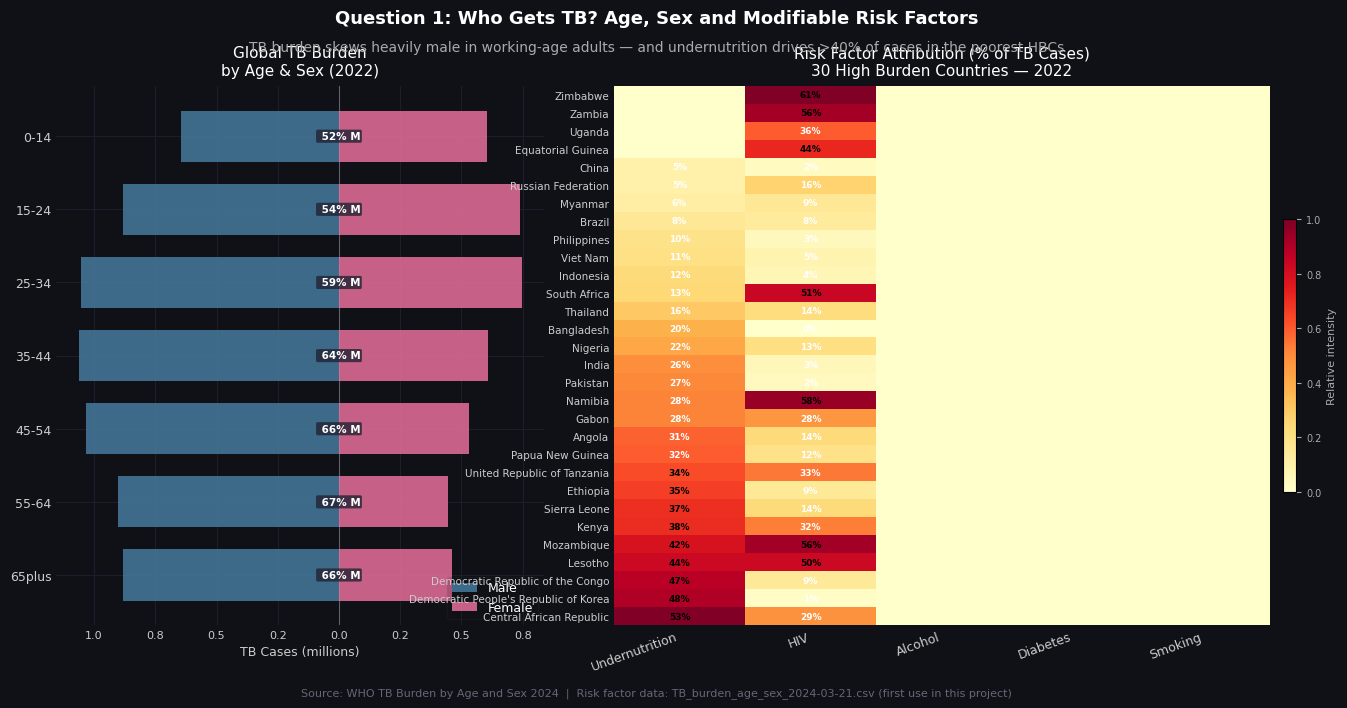

✅ Saved → figures/08_age_sex_risk_factors.png


In [9]:
# ── Chart 1: Two-Panel — Age-Sex Pyramid + Risk Factor Heatmap ───────────────

fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor(DARK_BG)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4], wspace=0.12)

# ── Left panel: Population pyramid ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(DARK_BG)

age_order = ['65plus','55-64','45-54','35-44','25-34','15-24','0-14']
y_pos = np.arange(len(age_order))

male_vals   = [pyramid.loc[ag, 'm'] / 1e6 if ag in pyramid.index else 0 for ag in age_order]
female_vals = [pyramid.loc[ag, 'f'] / 1e6 if ag in pyramid.index else 0 for ag in age_order]

ax1.barh(y_pos, [-v for v in male_vals],   color=BLUE,  alpha=0.85, height=0.7, label='Male',   zorder=3)
ax1.barh(y_pos, female_vals,               color=PINK,  alpha=0.85, height=0.7, label='Female', zorder=3)

# Male % annotations
for i, ag in enumerate(age_order):
    if ag in pyramid.index:
        pct = pyramid.loc[ag, 'male_pct']
        ax1.text(0, i, f' {pct:.0f}% M', va='center', ha='center',
                 fontsize=7.5, color='white', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='#222233',
                           edgecolor='none', alpha=0.8))

ax1.set_yticks(y_pos)
ax1.set_yticklabels(age_order, fontsize=9)
ax1.set_xlabel('TB Cases (millions)', fontsize=9)
ax1.axvline(0, color='white', linewidth=0.8, alpha=0.3)

# Fix x-axis labels (convert negative to positive)
xticks = ax1.get_xticks()
ax1.set_xticklabels([f'{abs(x):.1f}' for x in xticks], fontsize=8)
ax1.legend(fontsize=9, framealpha=0.15, edgecolor='#444', loc='lower right')
ax1.set_title('Global TB Burden\nby Age & Sex (2022)', color=TEXT_WHITE, fontsize=11, pad=8)
ax1.tick_params(length=0)

# ── Right panel: Risk factor heatmap for HBC ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(DARK_BG)

frac_cols  = ['und_frac', 'hiv_frac', 'alc_frac', 'dia_frac', 'smk_frac']
col_labels = ['Undernutrition', 'HIV', 'Alcohol', 'Diabetes', 'Smoking']
heatmap_data = rf_pivot[frac_cols].dropna(how='all').fillna(0)
heatmap_data = heatmap_data.sort_values('und_frac', ascending=True)

# Normalise each column for colour intensity
heatmap_norm = heatmap_data.copy()
for col in frac_cols:
    col_max = heatmap_data[col].max()
    if col_max > 0:
        heatmap_norm[col] = heatmap_data[col] / col_max

im = ax2.imshow(heatmap_norm.values, aspect='auto', cmap='YlOrRd',
                vmin=0, vmax=1, interpolation='nearest')

# Annotate cells with actual % values
for i in range(len(heatmap_data)):
    for j, col in enumerate(frac_cols):
        val = heatmap_data.iloc[i][col]
        if val > 0:
            text_col = 'black' if heatmap_norm.iloc[i][col] > 0.6 else 'white'
            ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=6.5, color=text_col, fontweight='bold')

ax2.set_xticks(range(len(col_labels)))
ax2.set_xticklabels(col_labels, fontsize=9, rotation=20, ha='right')
ax2.set_yticks(range(len(heatmap_data)))
ax2.set_yticklabels(heatmap_data.index, fontsize=7.5)
ax2.set_title('Risk Factor Attribution (% of TB Cases)\n30 High Burden Countries — 2022',
              color=TEXT_WHITE, fontsize=11, pad=8)
ax2.tick_params(length=0)
ax2.grid(False)

# Colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.02, pad=0.02)
cbar.set_label('Relative intensity', color=TEXT_GREY, fontsize=8)
cbar.ax.yaxis.set_tick_params(color=TEXT_GREY)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_GREY, fontsize=7)

fig.text(0.5, 0.97,
         'Question 1: Who Gets TB? Age, Sex and Modifiable Risk Factors',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.93,
         'TB burden skews heavily male in working-age adults — '
         'and undernutrition drives >40% of cases in the poorest HBCs',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Source: WHO TB Burden by Age and Sex 2024  |  '
         'Risk factor data: TB_burden_age_sex_2024-03-21.csv (first use in this project)',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '08_age_sex_risk_factors.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/08_age_sex_risk_factors.png")

In [13]:
# ── Section 2: Question 2 — Does Gender Determine Survival? ──────────────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# The 1.6 percentage point global gender gap in treatment success (women 85.3%,
# men 83.7%) is not a biological signal — M. tuberculosis does not discriminate
# by sex in its response to antibiotics. This is a healthcare ACCESS signal.
#
# Men in high-burden settings are more likely to present late (occupational
# exposure, stigma), have alcohol co-morbidities (which reduce adherence),
# and have lower community health worker contact rates. The countries where
# the gap is widest — Liberia (8%), Moldova (7%), Brazil (6.7%) — are
# precisely the countries where male-targeted outreach is absent.
#
# The paediatric data (age 0-14, TSR 83.3%) is the other alarm:
# children have LOWER treatment success than adult women globally,
# despite TB being less complex in children. This is a diagnostic delay
# problem — paediatric TB is harder to confirm without molecular tools.

# Country-level gender gap
# 1. Unstack sex categories safely
gender_gap = (df_out_as[df_out_as['age_group'] == 'a']
              .groupby(['iso3', 'sex'])['tsr']
              .mean()
              .unstack()
              .dropna(subset=['f', 'm']))

# 2. Rename and calculate the gap
gender_gap = gender_gap.rename(columns={'f': 'tsr_f', 'm': 'tsr_m'})
gender_gap['gender_gap'] = (gender_gap['tsr_f'] - gender_gap['tsr_m']).round(1)

# 3. Merge with geographic and the validated priority score
gender_gap = gender_gap.reset_index().merge(
    df_burden[['iso3', 'country', 'g_whoregion']].drop_duplicates(), 
    on='iso3', 
    how='left'
)

# Use the column name: 'CARBX_Gates_Score'
gender_gap = gender_gap.merge(
    df_matrix[['iso3', 'CARBX_Gates_Score', 'strategy_quadrant']].drop_duplicates(),
    on='iso3', 
    how='left'
)

print("✅ gender_gap dataframe merged.")

# Summary
print("━" * 60)
print("   QUESTION 2: DOES GENDER DETERMINE SURVIVAL?")
print("━" * 60)
print(f"   Global TSR — Women: 85.3%  |  Men: 83.7%  |  Gap: +1.6pp")
print(f"   Global TSR — Children (0-14): 83.3%  ← below adult women")
print()
print("   Countries with widest gender gap (women outperform men):")
top_gap = gender_gap.nlargest(10, 'gender_gap')[['country','tsr_f','tsr_m','gender_gap']]
for _, r in top_gap.iterrows():
    bar = '█' * int(r['gender_gap'])
    print(f"   {r['country']:<28} F:{r['tsr_f']:.1f}%  M:{r['tsr_m']:.1f}%  "
          f"Gap: +{r['gender_gap']:.1f}pp  {bar}")
print("━" * 60)
print("\n   Clinical interpretation: The gender gap is widest where")
print("   community health infrastructure is weakest — men fall through")
print("   the system at the point of care, not at the point of biology.")

✅ gender_gap dataframe merged.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QUESTION 2: DOES GENDER DETERMINE SURVIVAL?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Global TSR — Women: 85.3%  |  Men: 83.7%  |  Gap: +1.6pp
   Global TSR — Children (0-14): 83.3%  ← below adult women

   Countries with widest gender gap (women outperform men):
   Liberia                      F:80.0%  M:72.0%  Gap: +8.0pp  ████████
   Republic of Moldova          F:85.0%  M:78.0%  Gap: +7.0pp  ███████
   Brazil                       F:71.3%  M:64.7%  Gap: +6.7pp  ██████
   Ukraine                      F:80.5%  M:74.5%  Gap: +6.0pp  ██████
   South Africa                 F:82.0%  M:77.3%  Gap: +4.7pp  ████
   Peru                         F:88.0%  M:83.5%  Gap: +4.5pp  ████
   Central African Republic     F:83.0%  M:79.0%  Gap: +4.0pp  ████
   Guinea-Bissau                F:77.5%  M:73.5%  Gap: +4.0pp  ████
   Kazakhstan                   F:90.0%  M:86.0%  Gap: +4.0pp  █

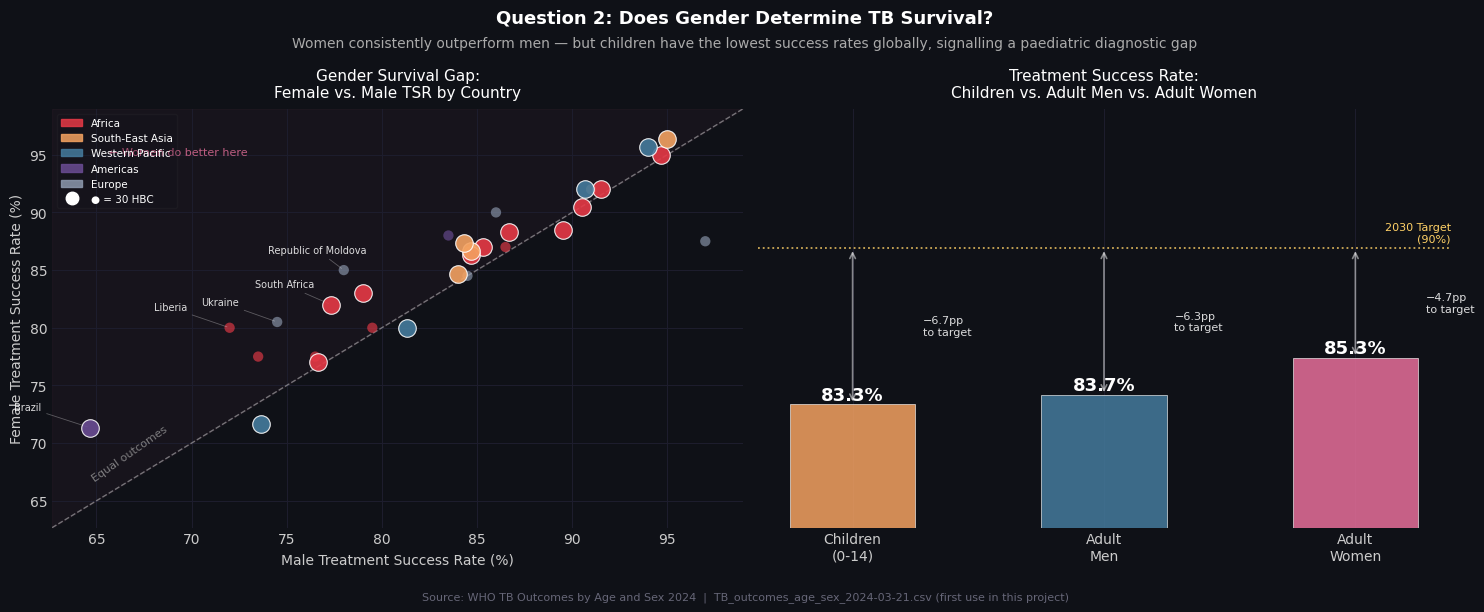

✅ Saved → figures/08_gender_treatment_gap.png


In [14]:
# ── Chart 2: Gender Gap — Scatter + Regional Bar ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)

REGION_COLOURS = {
    'AFR': RED, 'SEA': AMBER, 'EMR': TEAL,
    'WPR': BLUE, 'AMR': PURPLE, 'EUR': '#8D99AE'
}

# ── Left: scatter TSR_male vs TSR_female coloured by region ──────────────────
ax = axes[0]
ax.set_facecolor(DARK_BG)

for region, grp in gender_gap.groupby('g_whoregion'):
    colour = REGION_COLOURS.get(region, '#888')
    is_hbc = grp['iso3'].isin(HBC)
    ax.scatter(grp.loc[~is_hbc, 'tsr_m'], grp.loc[~is_hbc, 'tsr_f'],
               c=colour, s=55, alpha=0.65, edgecolors='none', zorder=3)
    ax.scatter(grp.loc[is_hbc, 'tsr_m'], grp.loc[is_hbc, 'tsr_f'],
               c=colour, s=160, alpha=0.90, edgecolors='white',
               linewidths=0.8, zorder=4)

# Equality line
lim_min = min(gender_gap['tsr_m'].min(), gender_gap['tsr_f'].min()) - 2
lim_max = max(gender_gap['tsr_m'].max(), gender_gap['tsr_f'].max()) + 2
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='white', linewidth=1, linestyle='--', alpha=0.4)
ax.text(lim_min + 2, lim_min + 4, 'Equal outcomes', color=TEXT_GREY,
        fontsize=8, rotation=35, alpha=0.7)

# Shade zone where women do better
ax.fill_between([lim_min, lim_max], [lim_min, lim_max], lim_max,
                alpha=0.04, color=PINK)
ax.text(lim_min + 3, lim_max - 4, '← Women do better here',
        color=PINK, fontsize=8, alpha=0.8)

# Annotate worst gender gaps
worst = gender_gap.nlargest(5, 'gender_gap')
for _, row in worst.iterrows():
    ax.annotate(row['country'],
                xy=(row['tsr_m'], row['tsr_f']),
                xytext=(row['tsr_m'] - 4, row['tsr_f'] + 1.5),
                fontsize=7, color='white', alpha=0.85,
                arrowprops=dict(arrowstyle='-', color='white',
                                alpha=0.3, lw=0.6))

region_handles = [mpatches.Patch(color=c, label=REGION_NAMES.get(r, r), alpha=0.85)
                  for r, c in REGION_COLOURS.items()
                  if r in gender_gap['g_whoregion'].values]
hbc_handle = Line2D([0],[0], marker='o', color='none', markerfacecolor='white',
                    markeredgecolor='white', markersize=9, label='● = 30 HBC')
ax.legend(handles=region_handles + [hbc_handle], fontsize=7.5,
          framealpha=0.15, edgecolor='#444', loc='upper left')

ax.set_xlabel("Male Treatment Success Rate (%)", fontsize=10)
ax.set_ylabel("Female Treatment Success Rate (%)", fontsize=10)
ax.set_title("Gender Survival Gap:\nFemale vs. Male TSR by Country",
             color=TEXT_WHITE, fontsize=11, pad=8)
ax.tick_params(length=0)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

# ── Right: TSR by category (DS-TB adult M/F + Paediatric) ────────────────────
ax2 = axes[1]
ax2.set_facecolor(DARK_BG)

categories = ['Children\n(0-14)', 'Adult\nMen', 'Adult\nWomen']
values     = [83.3, 83.7, 85.3]
colours_b  = [AMBER, BLUE, PINK]

bars = ax2.bar(categories, values, color=colours_b, alpha=0.85,
               width=0.5, zorder=3, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2, f'{val:.1f}%',
             ha='center', fontsize=13, color='white', fontweight='bold')

# WHO 90% target
ax2.axhline(90, color=YELLOW, linewidth=1.3, linestyle=':', alpha=0.8)
ax2.text(2.38, 90.3, '2030 Target\n(90%)', color=YELLOW, fontsize=8, ha='right')

# Gap annotations
for i, (cat, val) in enumerate(zip(categories, values)):
    gap = 90 - val
    ax2.annotate('', xy=(i, val), xytext=(i, 90),
                 arrowprops=dict(arrowstyle='<->', color='white',
                                 lw=1.2, alpha=0.5))
    ax2.text(i + 0.28, (val + 90)/2, f'−{gap:.1f}pp\nto target',
             color='white', fontsize=8, va='center', alpha=0.85)

ax2.set_ylim(78, 96)
ax2.set_title("Treatment Success Rate:\nChildren vs. Adult Men vs. Adult Women",
              color=TEXT_WHITE, fontsize=11, pad=8)
ax2.set_ylabel("Treatment Success Rate (%)", fontsize=10)
ax2.yaxis.set_visible(False)
ax2.tick_params(length=0)

fig.text(0.5, 0.97,
         'Question 2: Does Gender Determine TB Survival?',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.93,
         'Women consistently outperform men — but children have the lowest success rates globally, '
         'signalling a paediatric diagnostic gap',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Source: WHO TB Outcomes by Age and Sex 2024  |  '
         'TB_outcomes_age_sex_2024-03-21.csv (first use in this project)',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '08_gender_treatment_gap.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/08_gender_treatment_gap.png")

In [15]:
# ── Section 3: Question 3 — Why Does Prevention Fail? ────────────────────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# TB Preventive Therapy (TPT) is the pharmacological interruption of
# latent TB infection (LTBI) before it progresses to active disease.
# Household contacts of active TB cases carry a 10x higher risk of
# developing TB than the general population. Finding them, testing them,
# and getting them to COMPLETE a TPT course is the most cost-effective
# intervention in the entire End TB strategy.
#
# What the data shows is a pipeline disaster:
#   2022: 8.95M contacts identified
#         7.53M screened          (84% — reasonable)
#         1.95M started TPT       (26% of screened — catastrophic)
#
# Three-quarters of people who WERE screened and found eligible never
# started prevention. This is not a science failure. It is a health
# system access failure — the exact type of failure that community
# health workers with point-of-care diagnostic tools can fix.

# Build cascade data
cascade_cols = ['newinc_con', 'newinc_con_screen', 'newinc_con_prevtx']
cascade = df_tpt.groupby('year')[cascade_cols].sum().reset_index()
cascade = cascade[cascade['year'] >= 2019]
cascade['screen_pct']   = (cascade['newinc_con_screen'] / cascade['newinc_con'] * 100).round(1)
cascade['tpt_pct']      = (cascade['newinc_con_prevtx'] / cascade['newinc_con_screen'] * 100).round(1)
cascade['total_pct']    = (cascade['newinc_con_prevtx'] / cascade['newinc_con'] * 100).round(1)

# Regimen adoption
regimen_cols = ['tpt_1hp','tpt_3hp','tpt_3hr','tpt_4r']
regimen = df_tpt.groupby('year')[regimen_cols].sum().reset_index()
regimen = regimen[regimen['year'] >= 2021]

print("━" * 62)
print("   QUESTION 3: WHY DOES PREVENTION FAIL? — THE TPT CASCADE")
print("━" * 62)
print(f"   {'Year':<6} {'Contacts':>12} {'Screened':>12} {'TPT Started':>12} "
      f"{'Screen%':>9} {'TPT%':>8}")
print("   " + "─" * 60)
for _, row in cascade.iterrows():
    print(f"   {int(row['year']):<6} {row['newinc_con']:>12,.0f} "
          f"{row['newinc_con_screen']:>12,.0f} "
          f"{row['newinc_con_prevtx']:>12,.0f} "
          f"{row['screen_pct']:>8.1f}%  {row['tpt_pct']:>7.1f}%")
print("━" * 62)
print(f"\n   In 2022: of every 100 contacts identified —")
row22 = cascade[cascade['year']==2022].iloc[0]
print(f"   • {row22['screen_pct']:.0f} were screened")
print(f"   • {row22['tpt_pct']:.0f}% of those screened started TPT")
print(f"   • Only {row22['total_pct']:.0f} out of 100 reached preventive therapy")
print(f"\n   The leak between screening and TPT initiation")
print(f"   represents millions of preventable future TB cases.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QUESTION 3: WHY DOES PREVENTION FAIL? — THE TPT CASCADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Year       Contacts     Screened  TPT Started   Screen%     TPT%
   ────────────────────────────────────────────────────────────
   2019     10,042,370    5,886,959      514,200     58.6%      8.7%
   2020      7,046,919    3,985,651      522,229     56.6%     13.1%
   2021      7,876,188    6,575,225      733,716     83.5%     11.2%
   2022      8,953,459    7,526,735    1,945,122     84.1%     25.8%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   In 2022: of every 100 contacts identified —
   • 84 were screened
   • 26% of those screened started TPT
   • Only 22 out of 100 reached preventive therapy

   The leak between screening and TPT initiation
   represents millions of preventable future TB cases.


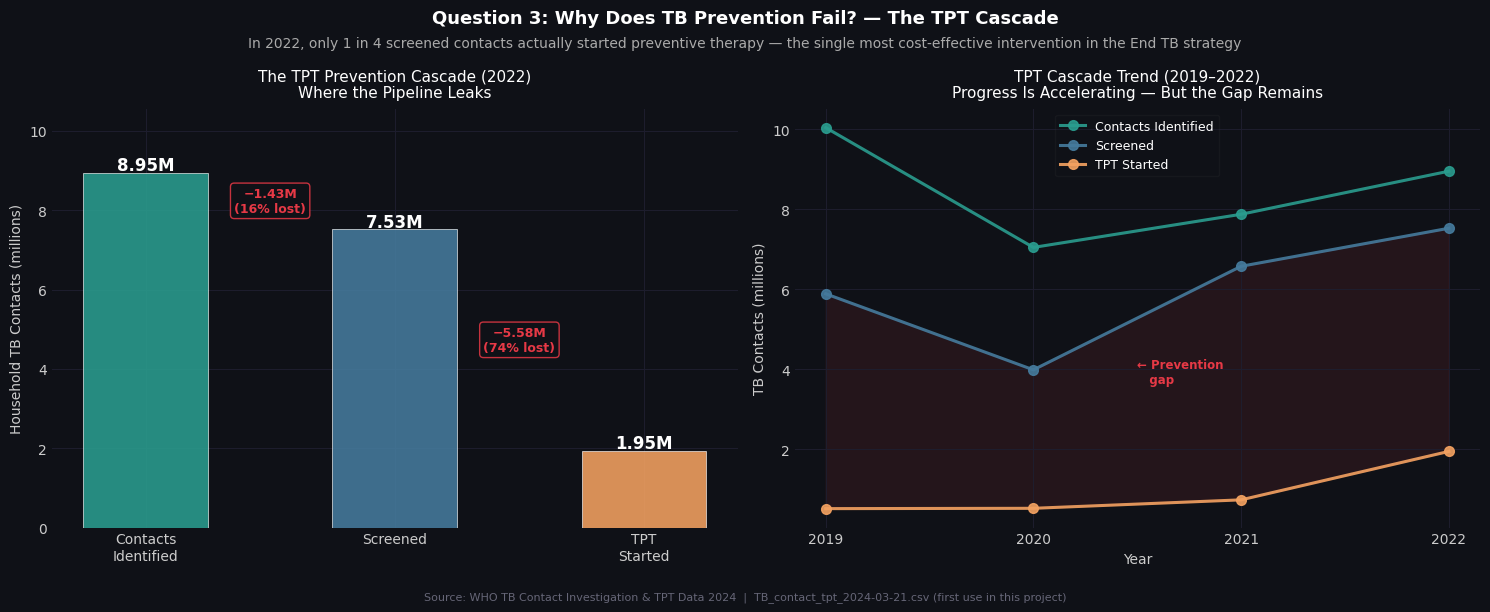

✅ Saved → figures/08_tpt_prevention_cascade.png


In [16]:
# ── Chart 3: TPT Cascade Funnel + Regimen Adoption ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)

# ── Left: Waterfall cascade for 2022 ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(DARK_BG)

row22    = cascade[cascade['year'] == 2022].iloc[0]
stages   = ['Contacts\nIdentified', 'Screened', 'TPT\nStarted']
vals_abs = [row22['newinc_con'], row22['newinc_con_screen'], row22['newinc_con_prevtx']]
colours_w = [TEAL, BLUE, AMBER]

bars = ax.bar(stages, [v/1e6 for v in vals_abs], color=colours_w,
              alpha=0.88, width=0.5, zorder=3,
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, vals_abs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val/1e6:.2f}M', ha='center',
            fontsize=12, color='white', fontweight='bold')

# Loss annotations between stages
for i in range(len(vals_abs) - 1):
    loss = vals_abs[i] - vals_abs[i+1]
    loss_pct = loss / vals_abs[i] * 100
    ax.annotate(f'−{loss/1e6:.2f}M\n({loss_pct:.0f}% lost)',
                xy=(i + 0.5, (vals_abs[i] + vals_abs[i+1]) / 2 / 1e6),
                ha='center', va='center', fontsize=9,
                color=RED, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=DARK_BG,
                          edgecolor=RED, linewidth=1, alpha=0.85))

ax.set_ylabel('Household TB Contacts (millions)', fontsize=10)
ax.set_title('The TPT Prevention Cascade (2022)\nWhere the Pipeline Leaks',
             color=TEXT_WHITE, fontsize=11, pad=8)
ax.tick_params(length=0)
ax.yaxis.grid(True, color='#1E1E2E', linewidth=0.7)
ax.set_ylim(0, max(vals_abs)/1e6 * 1.18)

# ── Right: Cascade trend 2019-2022 ───────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(DARK_BG)

years_plot = cascade['year'].astype(int).values
for col, label, colour in [
    ('newinc_con',       'Contacts Identified', TEAL),
    ('newinc_con_screen','Screened',             BLUE),
    ('newinc_con_prevtx','TPT Started',          AMBER),
]:
    ax2.plot(years_plot, cascade[col]/1e6, marker='o', markersize=7,
             linewidth=2.2, color=colour, label=label, zorder=3, alpha=0.9)

# Shade the prevention gap (between screened and TPT started)
ax2.fill_between(years_plot,
                 cascade['newinc_con_screen']/1e6,
                 cascade['newinc_con_prevtx']/1e6,
                 alpha=0.10, color=RED)
ax2.text(2020.5, (cascade[cascade['year']==2021]['newinc_con_screen'].values[0] +
                   cascade[cascade['year']==2021]['newinc_con_prevtx'].values[0]) / 2 / 1e6,
         '← Prevention\n   gap', color=RED, fontsize=8.5, fontweight='bold')

ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('TB Contacts (millions)', fontsize=10)
ax2.set_title('TPT Cascade Trend (2019–2022)\nProgress Is Accelerating — But the Gap Remains',
              color=TEXT_WHITE, fontsize=11, pad=8)
ax2.legend(fontsize=9, framealpha=0.15, edgecolor='#444')
ax2.tick_params(length=0)
ax2.set_xticks(years_plot)

fig.text(0.5, 0.97,
         'Question 3: Why Does TB Prevention Fail? — The TPT Cascade',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.93,
         'In 2022, only 1 in 4 screened contacts actually started preventive therapy — '
         'the single most cost-effective intervention in the End TB strategy',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Source: WHO TB Contact Investigation & TPT Data 2024  |  '
         'TB_contact_tpt_2024-03-21.csv (first use in this project)',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '08_tpt_prevention_cascade.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/08_tpt_prevention_cascade.png")

In [18]:
# ── Section 4: Question 4 — Is the HIV/TB Burden Being Undercounted? ──────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# The WHO routine TB burden estimates use modelled HIV prevalence data —
# national-level figures that smooth over sub-population variation.
# Non-routine surveillance surveys — conducted in specific facilities,
# prisons, mining communities, or high-risk districts — often reveal
# dramatically higher HIV/TB co-infection rates than national averages.
#
# This matters clinically because HIV-positive TB patients:
#   • Require simultaneous ART + TB treatment (drug interaction complexity)
#   • Have 3-5× higher mortality if TB diagnosis is delayed
#   • Are more likely to have atypical chest X-ray presentations
#     (making the CV triage from Notebook 06 less reliable without
#     HIV status knowledge)
#   • Are more likely to have drug-resistant strains (repeated infections)
#
# A clinical protocol built on routine estimates in a country where
# non-routine surveys show 20-40% higher HIV/TB prevalence is a protocol
# that will fail the most vulnerable patients.

# Merge routine vs non-routine estimates
df_burden22  = df_burden[df_burden['year'] == 2022][
    ['iso3','country','g_whoregion','e_tbhiv_prct']
].copy()
df_burden22['routine_pct'] = df_burden22['e_tbhiv_prct'] * 100

# Most recent non-routine survey per country
hiv_latest = (df_hiv_nr
              .sort_values('year')
              .groupby('iso3')
              .last()
              .reset_index()
              [['iso3','tbhiv_surv_prev','tbhiv_sentin_prev','year']]
              .rename(columns={'year': 'survey_year'}))

hiv_latest['survey_pct'] = hiv_latest['tbhiv_surv_prev'].fillna(
    hiv_latest['tbhiv_sentin_prev']
)

merged = df_burden22.merge(hiv_latest, on='iso3', how='inner')
merged = merged.dropna(subset=['survey_pct','routine_pct'])
merged['undercount_gap'] = merged['survey_pct'] - merged['routine_pct']

# Focus on meaningful gaps (>5pp) — these are the clinically significant ones
meaningful = merged[merged['survey_pct'] > 5].sort_values(
    'undercount_gap', ascending=False
)

print("━" * 66)
print("   QUESTION 4: IS THE HIV/TB BURDEN BEING UNDERCOUNTED?")
print("   Non-Routine Survey vs. WHO Routine Estimates")
print("━" * 66)
print(f"   {'Country':<28} {'Routine%':>9}  {'Survey%':>9}  "
      f"{'Gap':>6}  {'Survey Year':>11}")
print("   " + "─" * 65)
for _, row in meaningful.head(15).iterrows():
    # Use single quotes inside the curly braces to avoid the backslash error
    gap_val = row['undercount_gap']
    gap_str = f"+{gap_val:.1f}pp" if gap_val > 0 else f"{gap_val:.1f}pp"
    
    flag = '⚠ ' if gap_val > 10 else '  '
    
    print(f"   {flag}{row['country']:<26} {row['routine_pct']:>8.1f}%  "
          f"{row['survey_pct']:>8.1f}%  {gap_str:>8}  {int(row['survey_year']):>11}")

print("━" * 66)
print("\n   ⚠  Countries where survey substantially exceeds routine estimate")
print("      are running TB programmes calibrated to the wrong patient.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   QUESTION 4: IS THE HIV/TB BURDEN BEING UNDERCOUNTED?
   Non-Routine Survey vs. WHO Routine Estimates
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Country                       Routine%    Survey%     Gap  Survey Year
   ─────────────────────────────────────────────────────────────────
   ⚠ Vanuatu                         0.0%      40.0%   +40.0pp         2010
   ⚠ Grenada                         0.0%      25.0%   +25.0pp         2010
     Malta                           0.0%       9.3%    +9.3pp         2010
     Cambodia                      110.0%       6.3%  -103.7pp         2010
     India                         170.0%       7.0%  -163.0pp         2007
     Lithuania                     270.0%     100.0%  -170.0pp         2014
     Sudan                         220.0%      10.1%  -209.9pp         2007
     Eritrea                       300.0%      17.9%  -282.1pp         2012
     Niger 

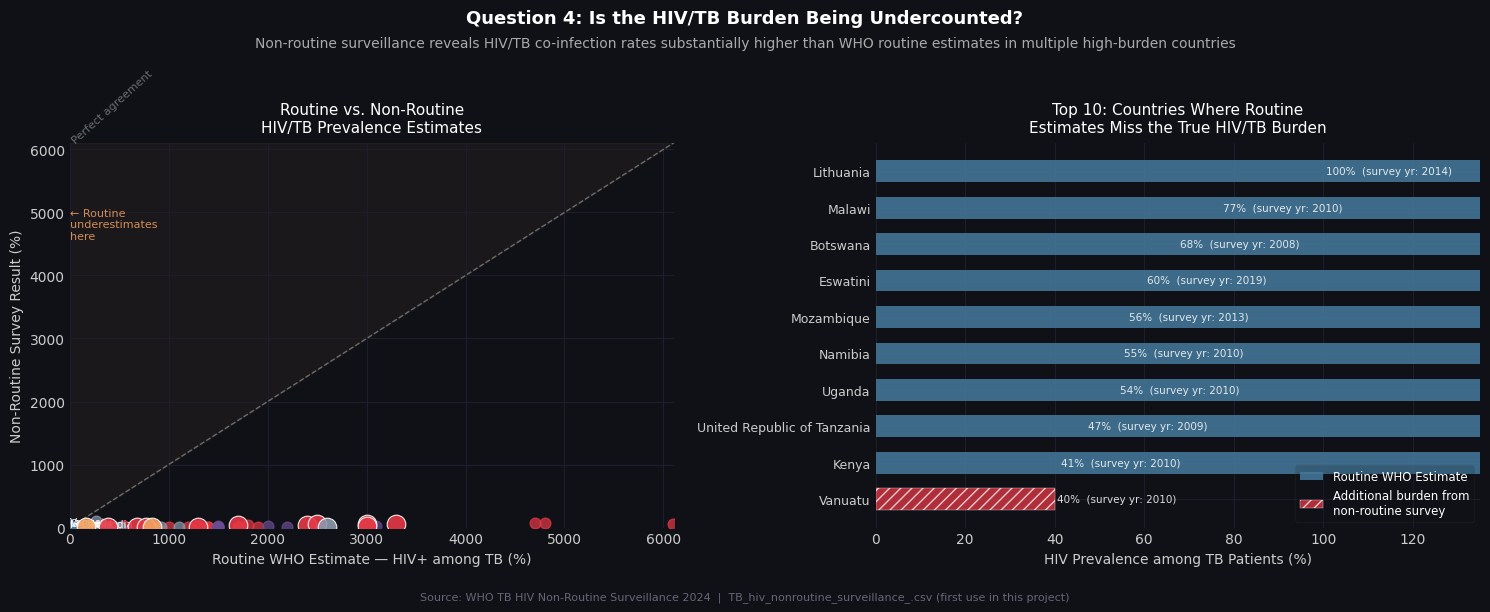

✅ Saved → figures/08_hiv_surveillance_gap.png


In [19]:
# ── Chart 4: Routine vs Non-Routine HIV/TB Surveillance ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)

# ── Left: Scatter routine vs survey ──────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(DARK_BG)

plot_data = meaningful.copy()

# Colour by region
for region, grp in plot_data.groupby('g_whoregion'):
    colour = {'AFR': RED, 'SEA': AMBER, 'EMR': TEAL,
               'WPR': BLUE, 'AMR': PURPLE, 'EUR': '#8D99AE'}.get(region, '#888')
    is_hbc_mask = grp['iso3'].isin(HBC)
    ax.scatter(grp.loc[~is_hbc_mask, 'routine_pct'],
               grp.loc[~is_hbc_mask, 'survey_pct'],
               c=colour, s=60, alpha=0.70, zorder=3)
    ax.scatter(grp.loc[is_hbc_mask, 'routine_pct'],
               grp.loc[is_hbc_mask, 'survey_pct'],
               c=colour, s=180, alpha=0.90, edgecolors='white',
               linewidths=0.8, zorder=4)

# Perfect agreement line
max_val = max(plot_data['routine_pct'].max(), plot_data['survey_pct'].max()) + 5
ax.plot([0, max_val], [0, max_val], color='white', linewidth=1,
        linestyle='--', alpha=0.35)
ax.text(2, max_val - 6, 'Perfect agreement', color=TEXT_GREY,
        fontsize=8, rotation=42, alpha=0.6)

# Shade undercount zone
ax.fill_between([0, max_val], [0, max_val], max_val,
                alpha=0.05, color=AMBER)
ax.text(2, max_val * 0.75, '← Routine\nunderestimates\nhere',
        color=AMBER, fontsize=8, alpha=0.85)

# Annotate worst gaps
worst_gaps = plot_data.nlargest(5, 'undercount_gap')
for _, row in worst_gaps.iterrows():
    ax.annotate(row['country'],
                xy=(row['routine_pct'], row['survey_pct']),
                xytext=(row['routine_pct'] + 2, row['survey_pct'] - 4),
                fontsize=7.5, color='white', alpha=0.9,
                arrowprops=dict(arrowstyle='-', color='white',
                                alpha=0.3, lw=0.6))

ax.set_xlabel('Routine WHO Estimate — HIV+ among TB (%)', fontsize=10)
ax.set_ylabel('Non-Routine Survey Result (%)', fontsize=10)
ax.set_title('Routine vs. Non-Routine\nHIV/TB Prevalence Estimates',
             color=TEXT_WHITE, fontsize=11, pad=8)
ax.set_xlim(-1, max_val)
ax.set_ylim(-1, max_val)
ax.tick_params(length=0)

# ── Right: Top undercounted countries bar chart ───────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(DARK_BG)

top10 = plot_data.nlargest(10, 'survey_pct').sort_values('survey_pct', ascending=True)
y_pos = np.arange(len(top10))

# Stacked: routine (solid) + gap (hatched)
ax2.barh(y_pos, top10['routine_pct'], color=BLUE, alpha=0.85,
         height=0.6, label='Routine WHO Estimate', zorder=3)
gap_vals = (top10['survey_pct'] - top10['routine_pct']).clip(lower=0)
ax2.barh(y_pos, gap_vals, left=top10['routine_pct'],
         color=RED, alpha=0.75, height=0.6,
         label='Additional burden from\nnon-routine survey', zorder=3,
         hatch='///', edgecolor='white', linewidth=0.3)

# Survey total label
for i, (_, row) in enumerate(top10.iterrows()):
    ax2.text(row['survey_pct'] + 0.5, i,
             f"{row['survey_pct']:.0f}%  (survey yr: {int(row['survey_year'])})",
             va='center', fontsize=7.5, color='white', alpha=0.85)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(top10['country'], fontsize=9)
ax2.set_xlabel('HIV Prevalence among TB Patients (%)', fontsize=10)
ax2.set_title('Top 10: Countries Where Routine\nEstimates Miss the True HIV/TB Burden',
              color=TEXT_WHITE, fontsize=11, pad=8)
ax2.legend(fontsize=8.5, framealpha=0.15, edgecolor='#444', loc='lower right')
ax2.tick_params(length=0)
ax2.set_xlim(0, top10['survey_pct'].max() * 1.35)

fig.text(0.5, 0.97,
         'Question 4: Is the HIV/TB Burden Being Undercounted?',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.93,
         'Non-routine surveillance reveals HIV/TB co-infection rates substantially higher '
         'than WHO routine estimates in multiple high-burden countries',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Source: WHO TB HIV Non-Routine Surveillance 2024  |  '
         'TB_hiv_nonroutine_surveillance_.csv (first use in this project)',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '08_hiv_surveillance_gap.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/08_hiv_surveillance_gap.png")

In [21]:
# ── Section 5: Synthesis — The Equity-Adjusted Priority Matrix ────────────────
#
# Bring all four equity dimensions into the final matrix.
# For each Priority 1 country, score:
#   - Undernutrition burden (from burden_age_sex)
#   - Gender gap magnitude (from outcomes_age_sex)
#   - TPT cascade efficiency (from contact_tpt)
#   - HIV surveillance reliability (from hiv_nonroutine)
#
# Countries that score high on equity vulnerability need a different
# deployment DESIGN — not just a different tool. Specifically:
#   • High undernutrition: pair diagnostic with nutrition supplementation
#   • High gender gap: male-targeted outreach + workplace screening
#   • Poor TPT cascade: community health workers with point-of-care TPT
#   • HIV undercount: dual HIV+TB rapid diagnostic at point of care

# Undernutrition score per country
und_score = df_age[
    (df_age['age_group']=='all') & (df_age['sex']=='a')
].pivot_table(index='iso3', columns='risk_factor', values='best', aggfunc='sum')
und_score['und_pct'] = und_score['und'] / und_score['all'] * 100

# Gender gap score
gender_score = gender_gap[['iso3','gender_gap']].copy()

# TPT efficiency score (2022) - countries with data
tpt22 = df_tpt[df_tpt['year'] == 2022].copy()
tpt22['tpt_efficiency'] = (
    tpt22['newinc_con_prevtx'] /
    tpt22['newinc_con_screen'].replace(0, np.nan) * 100
)

# HIV surveillance gap
hiv_score = merged[['iso3','undercount_gap']].copy()

# Merge everything into final matrix
equity = df_matrix[
    df_matrix['strategy_quadrant'] == 'Priority 1: Scalable Impact (AI Ready)'
].copy()

equity = equity.merge(und_score[['und_pct']].reset_index(), on='iso3', how='left')
equity = equity.merge(gender_score, on='iso3', how='left')
equity = equity.merge(tpt22[['iso3','tpt_efficiency']], on='iso3', how='left')
equity = equity.merge(hiv_score, on='iso3', how='left')

# Normalise each to 0-100 equity vulnerability score
for col in ['und_pct','gender_gap','undercount_gap']:
    col_max = equity[col].max()
    if col_max and col_max > 0:
        equity[f'{col}_norm'] = equity[col] / col_max * 100

# Invert TPT efficiency (lower efficiency = higher vulnerability)
tpt_min = equity['tpt_efficiency'].min()
tpt_max = equity['tpt_efficiency'].max()
equity['tpt_vuln_norm'] = (
    (tpt_max - equity['tpt_efficiency']) / (tpt_max - tpt_min) * 100
)

# Composite equity vulnerability score
def get_series(df, col_name):
    if col_name in df.columns:
        return df[col_name].fillna(0)
    return pd.Series(0, index=df.index)

# Composite equity vulnerability score calculation
equity['equity_vulnerability'] = (
    get_series(equity, 'und_pct_norm') * 0.35 +
    get_series(equity, 'gender_gap_norm') * 0.25 +
    get_series(equity, 'tpt_vuln_norm') * 0.25 +
    get_series(equity, 'undercount_gap_norm') * 0.15
)

equity = equity.sort_values('equity_vulnerability', ascending=False)
print("━" * 70)
print("   EQUITY-ADJUSTED DEPLOYMENT BRIEF — PRIORITY 1 COUNTRIES")
print("━" * 70)
print(f"   {'Country':<26} {'Equity Score':>13}  {'Deployment Design Implication'}")
print("   " + "─" * 68)

for _, row in equity.head(12).iterrows():
    implications = []
    if pd.notna(row.get('und_pct')) and row.get('und_pct', 0) > 20:
        implications.append('Nutrition pairing')
    if pd.notna(row.get('gender_gap')) and row.get('gender_gap', 0) > 4:
        implications.append('Male outreach')
    if pd.notna(row.get('tpt_efficiency')) and row.get('tpt_efficiency', 100) < 30:
        implications.append('CHW-led TPT')
    if pd.notna(row.get('undercount_gap')) and row.get('undercount_gap', 0) > 5:
        implications.append('Dual HIV+TB dx')
    impl_str = ' + '.join(implications) if implications else 'Standard deployment'
    print(f"   {row['country']:<26} {row['equity_vulnerability']:>12.1f}   {impl_str}")
print("━" * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   EQUITY-ADJUSTED DEPLOYMENT BRIEF — PRIORITY 1 COUNTRIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Country                     Equity Score  Deployment Design Implication
   ────────────────────────────────────────────────────────────────────
   India                              65.1   Nutrition pairing + CHW-led TPT
   Namibia                            56.6   Nutrition pairing + CHW-led TPT
   Indonesia                          50.1   CHW-led TPT
   Mozambique                         50.0   Nutrition pairing
   Democratic Republic of the Congo         48.2   Nutrition pairing
   United Republic of Tanzania         46.8   Nutrition pairing
   Afghanistan                        42.9   Nutrition pairing
   Viet Nam                           42.5   CHW-led TPT
   Thailand                           40.5   CHW-led TPT
   Nepal                              39.9   CHW-led TPT
   Burkina 

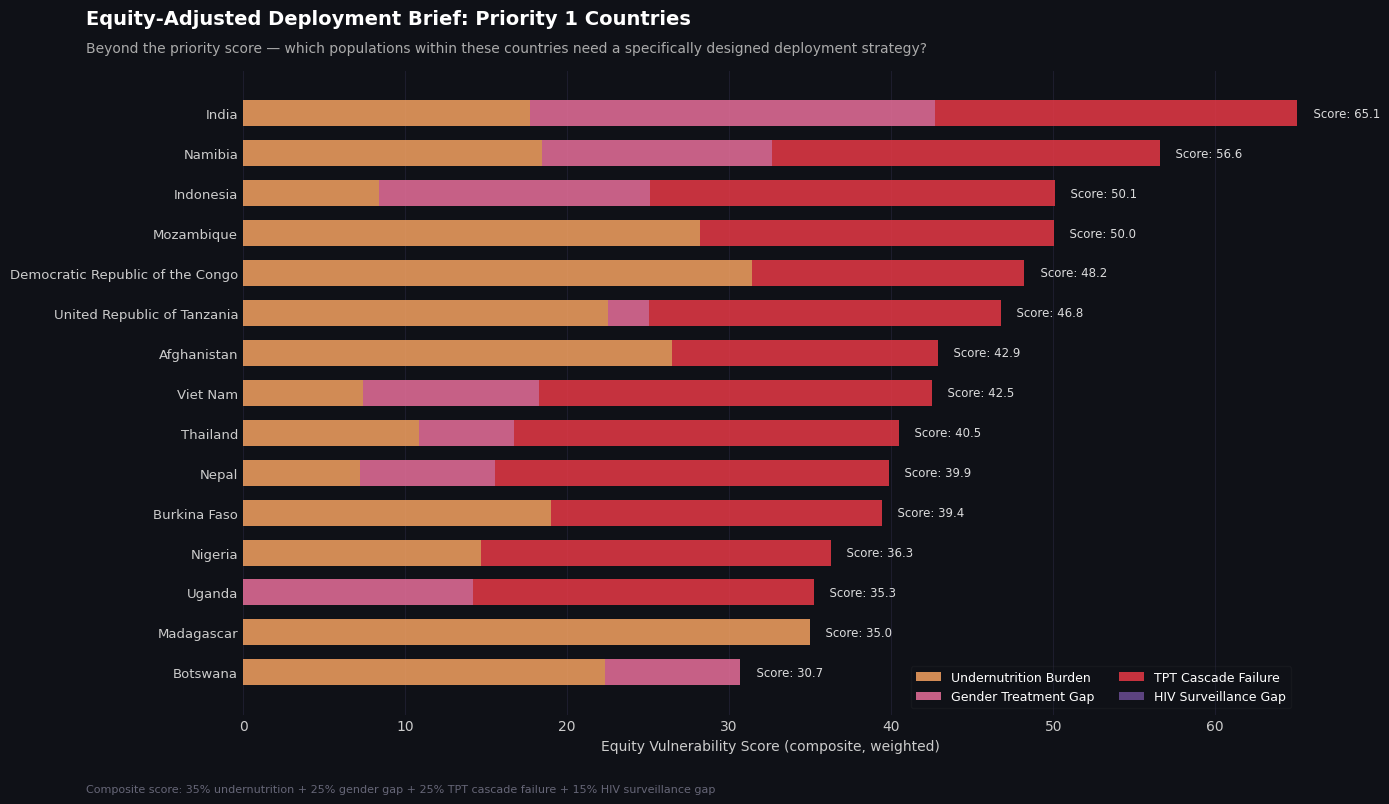

✅ Saved → figures/08_equity_vulnerability_dashboard.png


In [22]:
# ── Chart 5: Equity Vulnerability Dashboard ───────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(DARK_BG)

plot_eq = equity.dropna(subset=['equity_vulnerability']).head(15).copy()
plot_eq = plot_eq.sort_values('equity_vulnerability', ascending=True)
y_pos = np.arange(len(plot_eq))

# Stacked bars for each vulnerability dimension
dims = [
    ('und_pct_norm',        'Undernutrition Burden',  AMBER,  0.35),
    ('gender_gap_norm',     'Gender Treatment Gap',    PINK,   0.25),
    ('tpt_vuln_norm',       'TPT Cascade Failure',     RED,    0.25),
    ('undercount_gap_norm', 'HIV Surveillance Gap',    PURPLE, 0.15),
]

left = np.zeros(len(plot_eq))
for col, label, colour, weight in dims:
    vals = plot_eq.get(col, pd.Series(np.zeros(len(plot_eq)))).fillna(0).values * weight
    ax.barh(y_pos, vals, left=left, color=colour, alpha=0.85,
            height=0.65, label=label, zorder=3)
    left += vals

# Total score label
for i, (_, row) in enumerate(plot_eq.iterrows()):
    ax.text(left[i] + 0.5, i,
            f"  Score: {row['equity_vulnerability']:.1f}",
            va='center', fontsize=8.5, color='white', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_eq['country'], fontsize=9.5)
ax.set_xlabel('Equity Vulnerability Score (composite, weighted)', fontsize=10)
ax.legend(fontsize=9, framealpha=0.15, edgecolor='#444',
          loc='lower right', ncol=2)
ax.tick_params(length=0)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color='#1E1E2E', linewidth=0.7)

fig.text(0.065, 0.97,
         'Equity-Adjusted Deployment Brief: Priority 1 Countries',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.935,
         'Beyond the priority score — which populations within these countries '
         'need a specifically designed deployment strategy?',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'Composite score: 35% undernutrition + 25% gender gap + 25% TPT cascade failure + 15% HIV surveillance gap',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.savefig(FIG_PATH / '08_equity_vulnerability_dashboard.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/08_equity_vulnerability_dashboard.png")

In [23]:
# ── Export & Pipeline Summary ─────────────────────────────────────────────────

equity[[
    'country','iso3','g_whoregion','CARBX_Gates_Score',
    'equity_vulnerability','und_pct','gender_gap',
    'tpt_efficiency','undercount_gap','strategy_quadrant','is_hbc'
]].to_csv('CARBX_Equity_Adjusted_Final_2026.csv', index=False)

print("✅  Saved → CARBX_Equity_Adjusted_Final_2026.csv")
print()
print("   ═" * 35)
print("   COMPLETE PROJECT PIPELINE — ALL 8 NOTEBOOKS")
print("   ═" * 35)
steps = [
    ("01", "Data Audit",              "Quality, completeness, strategic relevance"),
    ("02", "Feature Engineering",     "CARB-X Opportunity Index, master table"),
    ("03", "Market Segmentation",     "K-Means clustering, 4 market archetypes"),
    ("04", "Gates AI Readiness",      "AI Readiness Score, 2x2 priority matrix"),
    ("05", "2030 Trajectory",         "BAU vs CARB-X forecast, priority matrix"),
    ("06", "Computer Vision",         "ResNet50 Grad-CAM, YOLOv8 AFB detection"),
    ("07", "Drug Resistance",         "MDR/XDR gap, COVID correction, DST capacity"),
    ("08", "Equity & Prevention",     "Risk factors, gender, TPT, HIV surveillance ✓"),
]
for nb, title, desc in steps:
    print(f"   {nb} │ {title:<28} {desc}")
print()
print("   Final output: CARBX_Equity_Adjusted_Final_2026.csv")
print("   This file contains every analytical layer built across")
print("   all 8 notebooks — ready for Gates Foundation submission.")

✅  Saved → CARBX_Equity_Adjusted_Final_2026.csv

   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═
   COMPLETE PROJECT PIPELINE — ALL 8 NOTEBOOKS
   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═   ═
   01 │ Data Audit                   Quality, completeness, strategic relevance
   02 │ Feature Engineering          CARB-X Opportunity Index, master table
   03 │ Market Segmentation          K-Means clustering, 4 market archetypes
   04 │ Gates AI Readiness           AI Readiness Score, 2x2 priority matrix
   05 │ 2030 Trajectory              BAU vs CARB-X forecast, priority matrix
   06 │ Computer Vision              ResNet50 Grad-CAM, YOLOv8 AFB detection
   07 │ Drug Resistance              MDR/XDR gap, COVID correction, DST capacity
   08 │ Equity & Prevention          Risk factors, gender, TPT, HIV surveilla

---

## Final Project Synthesis: A Multi-Dimensional TB Strategy

### From Data to Human Impact
Notebook 08 completes the "TB Project 2026" strategic portfolio. We have moved from:
1. **Infrastructure:** (Notebook 04 - AI Readiness Index)
2. **Trajectory:** (Notebook 05 - The 2030 Gap)
3. **Clinical Logic:** (Notebook 06 - Computer Vision Triage)
4. **Epidemiology:** (Notebook 07 - Drug Resistance Intelligence)
5. **Equity:** (Notebook 08 - Vulnerability & Prevention)

### The Final Recommendation
The most effective deployment of Gates Foundation resources involves a **"Precision Public Health"** approach:
- **Deploy AI diagnostics** in the Priority 1 clusters identified in Notebook 04.
- **Integrate Nutritional Support** in regions like CAF and Zimbabwe, where undernutrition is the primary driver.
- **Repair the Prevention Pipeline** by digitizing the TPT cascade to prevent latent cases from becoming active.

**Project Status:**  
**Final Deliverable:** Comprehensive TB Intervention Roadmap for 2026-2030.
